# Sparse identification of FitzHugh–Nagumo dynamics

This **deep-dive tutorial** walks through sparse drift inference for a FitzHugh–Nagumo (FHN) SDE.

**Goal.** Given noisy observations of the state, recover the sparse structure of the drift $f(x)$ by expressing it as with the elements of a polynomial library $\Theta\,\phi(x)$ and placing a **Laplace prior** on the coefficient matrix $\Theta$. This is a Bayesian SINDy-style approach. We fit via **SVI with AutoDelta** (MAP estimation) and then compare the recovered coefficients and filtered trajectories against ground truth.

**What is known.**
- Initial state distribution: $x_0 \sim \mathcal{N}(0, I)$.
- Observation operator $H$ (identity here, observing both states).
- Polynomial library $\phi(x)$ (monomials up to degree 3).

**What is inferred.**
- Drift coefficient matrix $\Theta \in \mathbb{R}^{2 \times 10}$ via MAP (Laplace prior promotes sparsity).
- Diffusion coefficient $\sigma_x > 0$ (HalfNormal prior).
- Observation noise standard deviation $\sigma_y > 0$ (HalfNormal prior).

## FitzHugh–Nagumo Model

### State SDE

The state $x_t = (v_t, w_t)^\top \in \mathbb{R}^2$ evolves as an Itô SDE:

$$
dx_t = f(x_t)\,dt + \sigma_x\,dW_t,
$$

where $W_t$ is a standard 2-dimensional Brownian motion and the true drift is

$$
f(x) = \begin{pmatrix} v - \tfrac{1}{3}v^3 - w + I \\ a\,(v + b - c\,w) \end{pmatrix}.
$$

Parameters are fixed at $a = 0.08$, $b = 0.7$, $c = 0.8$, $I = 0.5$. The true noise values used to generate data are $\sigma_x = 0.01$ and $\sigma_y = 0.1$, but **both are treated as unknown during inference**.

### Observation process

Observations are collected at discrete times $t_1 < t_2 < \cdots < t_n$:

$$
y_k = H\,x_{t_k} + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0,\,\sigma_y^2 I),
$$

where $H = I_2$ (both states observed).

### Initial condition

$$
x_0 \sim \mathcal{N}(0, I_2).
$$

### Inferred quantities

We do **not** know $f$, $\sigma_x$, or $\sigma_y$. We parameterise the drift as

$$
f(x) \approx \Theta\,\phi(x),
$$

where $\phi(x) \in \mathbb{R}^{10}$ is a polynomial library (all monomials in $v, w$ up to degree 3). The full set of inferred quantities and their priors is:

$$
\Theta \sim \mathrm{Laplace}(0,\; 0.1) \quad \text{(promotes sparsity)},
$$
$$
\sigma_x \sim \mathrm{HalfNormal}(0.1), \qquad \sigma_y \sim \mathrm{HalfNormal}(0.5).
$$

All three are inferred jointly via MAP (SVI with AutoDelta).

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDelta

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    SDESimulator,
)

import matplotlib.pyplot as plt


## True system

Define the true FitzHugh–Nagumo drift. We will later build the full DynamicalModel by piping in this drift and spreading shared arguments from a dict.

In [2]:
# FitzHugh–Nagumo parameters
_a, _b, _c, _I = 0.08, 0.7, 0.8, 0.5

def fitzhugh_nagumo_drift(x):
    v, w = x[0], x[1]
    dv = v - (1/3) * v**3 - w + _I
    dw = _a * (v + _b - _c * w)
    return jnp.array([dv, dw])

state_dim = 2

## Model configuration

Constants used for data generation and inference setup.

| Symbol | Role | Value | Status |
|---|---|---|---|
| $\sigma_x^{\mathrm{true}}$ | true diffusion coefficient (data generation only) | `0.01` | **inferred** |
| $\sigma_y^{\mathrm{true}}$ | true observation noise std (data generation only) | `0.1` | **inferred** |
| $x_0 \sim \mathcal{N}(0, I_2)$ | initial state prior | covariance = `I` | known |
| $\Delta t$ | observation spacing | `0.1` | known |
| $T$ | total time span | `[0, 50)` | known |

In [3]:
# True values used ONLY for data generation — both are inferred during model discovery
sigma_x_true = 0.01   # true diffusion coefficient
sigma_y_true = 0.1    # true observation noise std

# observation times t_1, ..., t_n  (spacing Delta_t = 0.1, span [0, 50))
obs_times = jnp.arange(0.0, 50.0, 0.1)

observation_dim = 2  # observation_dim=1 also works (observe only v)

key = jr.PRNGKey(0)
key, k_data, k_svi, k_nuts, k_filter = jr.split(key, 5)

## DynamicalModel construction helpers

The Dynestyx `DynamicalModel` needs three pieces:

- **Initial condition** — $x_0 \sim \mathcal{N}(0, I_2)$. Fixed; collected in `initial_condition_kwargs`.
- **Observation model** — $y_k = H\,x_{t_k} + \varepsilon_k$ with $\varepsilon_k \sim \mathcal{N}(0, \sigma_y^2 I_2)$. Constructed inside each model function because $\sigma_y$ is inferred.
- **State evolution** — wraps the drift $f$ and the diffusion $\sigma_x I_2$. Constructed inside each model function because $\sigma_x$ is inferred.

`make_state_evolution(drift_fn, diffusion_coeff)` is a helper that accepts whichever diffusion coefficient (true or inferred) is provided.

In [4]:
# H in y_k = H x_{t_k} + eps_k  (identity: observe all states)
H_obs = jnp.eye(observation_dim, state_dim)

# Only the initial condition is shared and fixed; observation model and state
# evolution are constructed inside each model function because sigma_x and sigma_y
# are inferred.
initial_condition_kwargs = dict(
    # x_0 ~ N(0, I_2)
    initial_condition=dist.MultivariateNormal(
        loc=jnp.zeros(state_dim),
        covariance_matrix=jnp.eye(state_dim),
    ),
)


from cd_dynamax import adjust_rhs

def make_state_evolution(drift_fn, diffusion_coeff):
    """Wrap a drift f(x,u,t) into a ContinuousTimeStateEvolution.

    diffusion_coeff: scalar sigma_x  in  dx = f(x) dt + sigma_x dW_t.
    adjust_rhs clips state and derivatives to [-100,100] / [-1000,1000]
    to prevent SDE solver blow-up.
    """
    return ContinuousTimeStateEvolution(
        drift=lambda x, u, t: adjust_rhs(x, drift_fn(x, u, t)),
        # sigma_x I_2  (isotropic, constant diffusion)
        diffusion_coefficient=lambda x, u, t: diffusion_coeff * jnp.eye(state_dim),
    )


## Data generation

We simulate from the **true** FHN drift using an SDE simulator. The model observes the state at `obs_times` with Gaussian noise.

In [5]:
# Data generation: simulate  dx_t = f_true(x_t) dt + sigma_x_true dW_t
#                             y_k = H x_{t_k} + N(0, sigma_y_true^2 I)
# Uses the true (known) noise values — these are NOT passed to the inference model.
def model_with_true_drift(obs_times=None, obs_values=None):
    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(
            lambda x, u, t: fitzhugh_nagumo_drift(x),
            diffusion_coeff=sigma_x_true,
        ),
        # y_k = H x_{t_k} + N(0, sigma_y_true^2 I)
        observation_model=LinearGaussianObservation(
            H=H_obs,
            R=sigma_y_true**2 * jnp.eye(observation_dim),
        ),
        **initial_condition_kwargs,
    ), obs_times=obs_times, obs_values=obs_values)

predictive = Predictive(model_with_true_drift, num_samples=1, exclude_deterministic=False)
with SDESimulator():
    synthetic = predictive(k_data, obs_times=obs_times)

obs_values = synthetic["observations"][0]  # y_k  shape (n_obs, observation_dim)
states = synthetic["states"][0]            # x_{t_k}  shape (n_obs, state_dim)
times_1d = jnp.asarray(obs_times).squeeze()

### Data visualization

Time series of the latent state and noisy observations, and the phase-space trajectory.

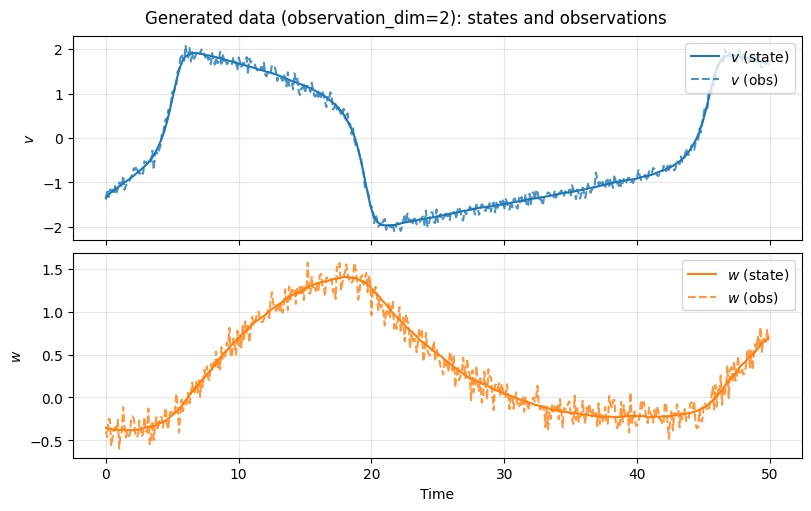

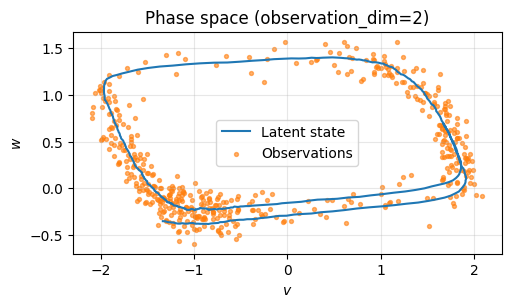

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
axes[0].plot(times_1d, states[:, 0], label="$v$ (state)", color="C0")
axes[0].plot(times_1d, obs_values[:, 0], linestyle="--", alpha=0.8, label="$v$ (obs)", color="C0")
axes[0].set_ylabel("$v$")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[1].plot(times_1d, states[:, 1], label="$w$ (state)", color="C1")
if observation_dim >= 2:
    axes[1].plot(times_1d, obs_values[:, 1], linestyle="--", alpha=0.8, label="$w$ (obs)", color="C1")
axes[1].set_ylabel("$w$")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
fig.suptitle(f"Generated data (observation_dim={observation_dim}): states and observations")
plt.show()

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.plot(states[:, 0], states[:, 1], color="C0", label="Latent state", linewidth=1.5)
if observation_dim == 1:
    ax.scatter(obs_values[:, 0], jnp.zeros_like(obs_values[:, 0]), s=8, alpha=0.6, color="C1", label="Observations (v)")
else:
    ax.scatter(obs_values[:, 0], obs_values[:, 1], s=8, alpha=0.6, color="C1", label="Observations")
ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title(f"Phase space (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()

## Polynomial library and true coefficients

Library terms (monomials in $v$, $w$): $1$, $v$, $w$, $v^2$, $vw$, $w^2$, $v^3$, $v^2w$, $vw^2$, $w^3$. The true FHN drift uses only a subset. We build the coefficient matrix $\Theta \in \mathbb{R}^{2 \times 10}$ so that $f(x) = \Theta\,\phi(x)$.

In [7]:
TERM_NAMES = ["1", "v", "w", "v²", "vw", "w²", "v³", "v²w", "vw²", "w³"]
N_TERMS = len(TERM_NAMES)


def monomials(x):
    """Evaluate polynomial basis at state x = (v, w). Returns (N_TERMS,)."""
    v, w = x[0], x[1]
    return jnp.array([
        1.0, v, w, v**2, v * w, w**2, v**3, v**2 * w, v * w**2, w**3,
    ])


# True coefficient matrix (state_dim x N_TERMS) for FHN: dv = v - v³/3 - w + I, dw = _a*(v + _b - _c*w)
true_Theta = jnp.zeros((state_dim, N_TERMS))
true_Theta = true_Theta.at[0, 0].set(_I)       # 1
true_Theta = true_Theta.at[0, 1].set(1.0)     # v
true_Theta = true_Theta.at[0, 2].set(-1.0)    # w
true_Theta = true_Theta.at[0, 6].set(-1.0 / 3)  # v³
true_Theta = true_Theta.at[1, 0].set(_a * _b)  # 1
true_Theta = true_Theta.at[1, 1].set(_a)       # v
true_Theta = true_Theta.at[1, 2].set(-_a * _c)  # w

print("True coefficient matrix (rows: dv, dw; cols: library terms):")
print(jnp.round(true_Theta, 4))

True coefficient matrix (rows: dv, dw; cols: library terms):
[[ 0.5     1.     -1.      0.      0.      0.     -0.3333  0.      0.
   0.    ]
 [ 0.056   0.08   -0.064   0.      0.      0.      0.      0.      0.
   0.    ]]


## Model discovery

Build a Dynestyx SDE model that jointly infers:
- $\Theta$ — drift coefficients with a sparsifying Laplace prior,
- $\sigma_x$ — diffusion coefficient with a HalfNormal prior,
- $\sigma_y$ — observation noise std with a HalfNormal prior.

The observation model and state evolution are constructed inside the model function so that the sampled $\sigma_x$ and $\sigma_y$ flow through to the likelihood.

In [8]:
def model_with_polynomial_drift(obs_times=None, obs_values=None):
    # Theta ~ Laplace(0, 0.1)  iid  for each entry in R^{2 x 10}
    # Laplace prior promotes sparsity: entries not supported by data shrink toward 0
    Theta = numpyro.sample(
        "Theta",
        dist.Laplace(0.0, 0.1).expand([state_dim, N_TERMS]).to_event(2),
    )

    # sigma_x ~ HalfNormal(0.1)  —  diffusion coefficient in  dx = f(x) dt + sigma_x dW_t
    sigma_x = numpyro.sample("sigma_x", dist.HalfNormal(0.1))

    # sigma_y ~ HalfNormal(0.5)  —  per-component std in  y_k = H x_{t_k} + N(0, sigma_y^2 I)
    sigma_y = numpyro.sample("sigma_y", dist.HalfNormal(0.5))

    # f(x) = Theta phi(x)  approximates the unknown drift
    def drift(x, u, t):
        phi = monomials(x)   # phi(x) in R^{N_TERMS}
        return Theta @ phi   # R^{state_dim}

    # Full model:  dx = Theta phi(x) dt + sigma_x dW_t,  y_k = H x_{t_k} + N(0, sigma_y^2 I)
    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(drift, diffusion_coeff=sigma_x),
        observation_model=LinearGaussianObservation(
            H=H_obs,
            R=sigma_y**2 * jnp.eye(observation_dim),
        ),
        **initial_condition_kwargs,
    ), obs_times=obs_times, obs_values=obs_values)



Build the conditioned model via filtering + data conditioning

In [9]:
def data_conditioned_model(obs_times=None, obs_values=None):
    with Filter():
        return model_with_polynomial_drift(obs_times=obs_times, obs_values=obs_values)

Run SVI for MAP estimation...

In [10]:
# Note that we get "close" to a good model within 1000 steps, but the last 3000 steps are needed to get a high-fidelity final MAP estimate here.
num_steps = 4000
optimizer = numpyro.optim.Adam(step_size=1e-2)
guide = AutoDelta(data_conditioned_model)
svi = SVI(data_conditioned_model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(k_svi, num_steps=num_steps, obs_times=obs_times, obs_values=obs_values)

median = guide.median(svi_result.params)
Theta_inferred  = median["Theta"]    # (state_dim, N_TERMS)
sigma_x_inferred = float(median["sigma_x"])  # scalar
sigma_y_inferred = float(median["sigma_y"])  # scalar

print(f"Inferred sigma_x = {sigma_x_inferred:.4f}  (true = {sigma_x_true:.4f})")
print(f"Inferred sigma_y = {sigma_y_inferred:.4f}  (true = {sigma_y_true:.4f})")

100%|██████████| 4000/4000 [24:05<00:00,  2.77it/s, init loss: 887.9816, avg. loss [3801-4000]: -855.6309]

Inferred sigma_x = 0.0071  (true = 0.0100)
Inferred sigma_y = 0.1013  (true = 0.1000)


### SVI loss curve

The negative ELBO decreases as the MAP estimate is refined.

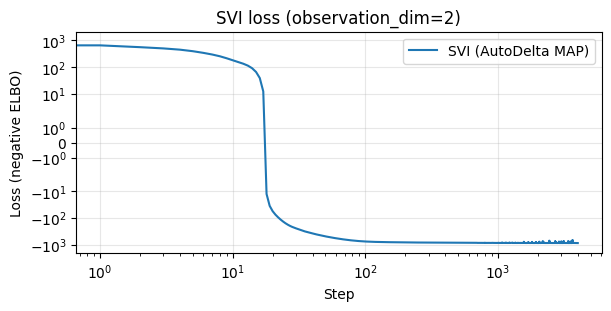

In [11]:
fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(svi_result.losses, color="C0", label="SVI (AutoDelta MAP)")
ax.set_yscale("symlog")
ax.set_xscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss (negative ELBO)")
ax.set_title(f"SVI loss (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Parameter recovery

Compare true vs inferred values for all inferred quantities:
- **Drift coefficients** $\Theta$: side-by-side heatmaps (red = positive, blue = negative). The Laplace prior shrinks unused terms toward zero, recovering the sparse structure.
- **Noise scales** $\sigma_x$, $\sigma_y$: bar chart comparing inferred MAP values against the ground truth used for data generation.

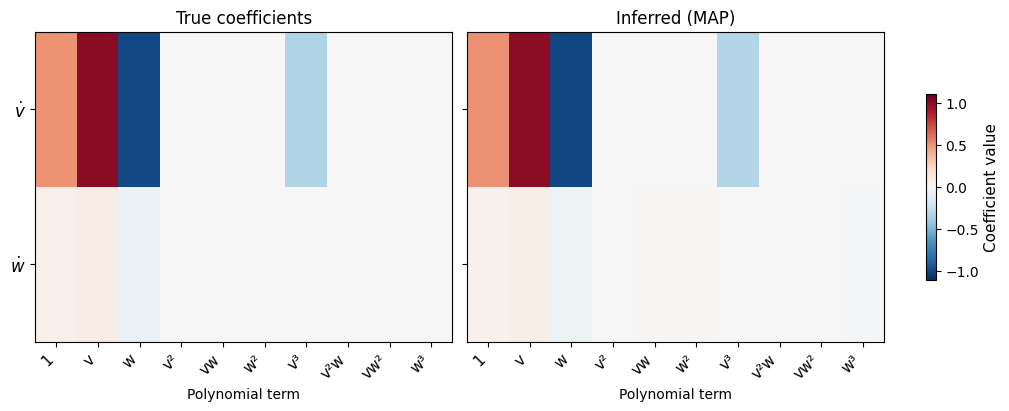

In [12]:
vmax = max(float(jnp.abs(true_Theta).max()), float(jnp.abs(Theta_inferred).max())) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)

im0 = axes[0].imshow(
    jnp.asarray(true_Theta),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].set_xticks(range(N_TERMS))
axes[0].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels([r"$\dot{v}$", r"$\dot{w}$"], fontsize=12)
axes[0].set_title("True coefficients")
axes[0].set_xlabel("Polynomial term")

im1 = axes[1].imshow(
    jnp.asarray(Theta_inferred),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].set_xticks(range(N_TERMS))
axes[1].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels([r"$\dot{v}$", r"$\dot{w}$"], fontsize=12)
axes[1].set_title("Inferred (MAP)")
axes[1].set_xlabel("Polynomial term")

cbar = fig.colorbar(im1, ax=axes, shrink=0.6, aspect=20)
cbar.set_label("Coefficient value", fontsize=11)
plt.show()

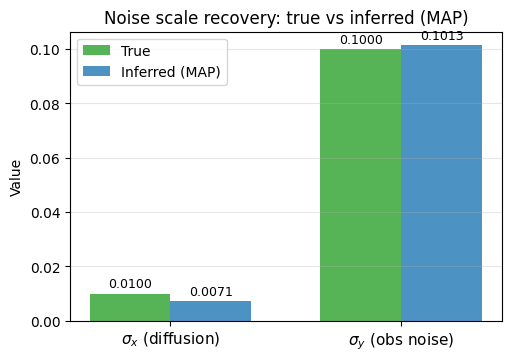

  sigma_x: true=0.0100, inferred=0.0071, relative error=29.3%
  sigma_y: true=0.1000, inferred=0.1013, relative error=1.3%


In [13]:
labels  = [r"$\sigma_x$ (diffusion)", r"$\sigma_y$ (obs noise)"]
truths  = [sigma_x_true,     sigma_y_true]
inferred = [sigma_x_inferred, sigma_y_inferred]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
bars_true = ax.bar([v - width/2 for v in x], truths,   width, label="True",     color="C2", alpha=0.8)
bars_inf  = ax.bar([v + width/2 for v in x], inferred, width, label="Inferred (MAP)", color="C0", alpha=0.8)

# Annotate bar tops with values
for bar in bars_true:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars_inf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Value")
ax.set_title("Noise scale recovery: true vs inferred (MAP)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()

# Relative errors
for name, t, i in zip(["sigma_x", "sigma_y"], truths, inferred):
    rel_err = abs(i - t) / t * 100
    print(f"  {name}: true={t:.4f}, inferred={i:.4f}, relative error={rel_err:.1f}%")

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_48969/2550543806.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend(


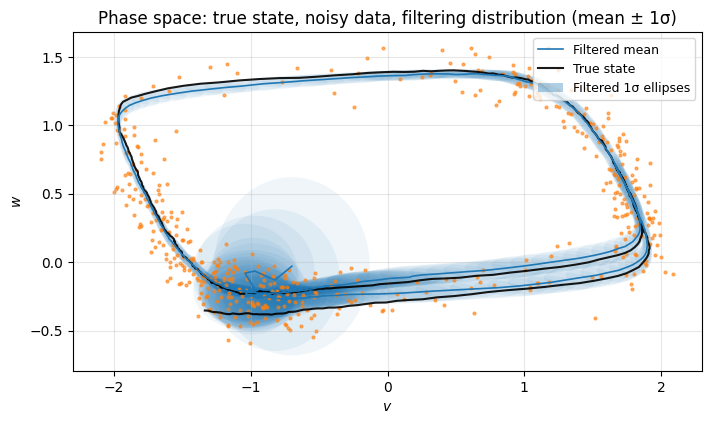

In [16]:
result = Predictive(
    data_conditioned_model,
    params={"Theta": Theta_inferred},
    num_samples=1,
    exclude_deterministic=False,
)(k_filter, obs_times=obs_times, obs_values=obs_values)

filtered_mean = jnp.squeeze(result["f_filtered_states_mean"], axis=0)  # (T+1, 2)
filtered_cov_diag = jnp.squeeze(result["f_filtered_states_cov_diag"], axis=0)  # (T+1, 2)
filtered_std = jnp.sqrt(jnp.maximum(filtered_cov_diag, 1e-10))

# Align lengths: filter may return T+1 (includes prior at t0)
n = min(len(times_1d), filtered_mean.shape[0])
t_plot = times_1d[:n]
fm = filtered_mean[:n]
fs = filtered_std[:n]
st = states[:n]
obs = obs_values[:n]

from matplotlib.patches import Ellipse, Rectangle
from matplotlib.collections import PatchCollection

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

# 1-sigma uncertainty ellipses at each timepoint.
# Covariance is diagonal, so ellipses are axis-aligned:
#   semi-axis along v = fs[i, 0],  semi-axis along w = fs[i, 1].
ellipses = [
    Ellipse(xy=(fm[i, 0], fm[i, 1]), width=2 * fs[i, 0], height=2 * fs[i, 1])
    for i in range(len(fm))
]
ec = PatchCollection(ellipses, facecolor="C0", edgecolor="none", alpha=0.07)
ax.add_collection(ec)

ax.plot(st[:, 0], st[:, 1], "k-", label="True state", linewidth=1.5, alpha=0.9)
ax.scatter(obs[:, 0], obs[:, 1], s=4, c="C1", alpha=0.6, label="Noisy observations")
ax.plot(fm[:, 0], fm[:, 1], "C0-", label="Filtered mean", linewidth=1.2)
ax.legend(
    handles=[
        ax.lines[-1],                                          # filtered mean line
        ax.collections[-2],                                    # noisy obs scatter
        ax.lines[0],                                           # true state line
        Rectangle((0, 0), 1, 1, facecolor="C0", alpha=0.35),  # proxy for ellipses
    ],
    labels=["Filtered mean", "Noisy observations", "True state", "Filtered 1σ ellipses"],
    loc="upper right", fontsize=9,
)

ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title("Phase space: true state, noisy data, filtering distribution (mean ± 1σ)")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
ax.autoscale_view()
plt.show()